# **Bank Customer Churn**

Cristian David Rodriguez Montes

Librerias importadas

In [1]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, normaltest, f_oneway
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import shap
import os
import joblib

import warnings
warnings.filterwarnings("ignore")

c:\Users\casar\OneDrive\Empleos\Skandia\Ciencia de Datos JR\PruebaTecnica\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv(f'datasets\\train.csv')
df.head(5)

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15674932,Okwudilichukwu,668,France,Male,33.0,3,0.00,2,1.0,0.0,181449.97,0
1,1,15749177,Okwudiliolisa,627,France,Male,33.0,1,0.00,2,1.0,1.0,49503.50,0
2,2,15694510,Hsueh,678,France,Male,40.0,10,0.00,2,1.0,0.0,184866.69,0
3,3,15741417,Kao,581,France,Male,34.0,2,148882.54,1,1.0,1.0,84560.88,0
4,4,15766172,Chiemenam,716,Spain,Male,33.0,5,0.00,2,1.0,1.0,15068.83,0


Parentesis: Con el fin de realizar el ejercicio con un columna JSON se realizara la siguiente operación:


In [3]:
df_json = df.copy()

df_json["CustomerProfile"] = df.apply(
    lambda row: json.dumps({
        "CreditScore": row["CreditScore"],
        "Age": row["Age"],
        "Balance": row["Balance"],
        "Products": row["NumOfProducts"]
    }),
    axis=1
)
df_json['CustomerProfile'].head()

0    {"CreditScore": 668, "Age": 33.0, "Balance": 0...
1    {"CreditScore": 627, "Age": 33.0, "Balance": 0...
2    {"CreditScore": 678, "Age": 40.0, "Balance": 0...
3    {"CreditScore": 581, "Age": 34.0, "Balance": 1...
4    {"CreditScore": 716, "Age": 33.0, "Balance": 0...
Name: CustomerProfile, dtype: str

Para convertirlas nuevamente en columnas:

In [4]:
profile = df_json["CustomerProfile"].apply(json.loads)

profile = pd.json_normalize(profile)

profile.head()

,CreditScore,Age,Balance,Products
0,668,33.0,0.00,2
1,627,33.0,0.00,2
2,678,40.0,0.00,2
3,581,34.0,148882.54,1
4,716,33.0,0.00,2


### **Acerca del dataset:**
- Customer ID: Identificador del cliente.
- Surname: Apellido del cliente.
- Credit Score: Score crediticio del cliente.
- Geography: Pais del cliente.
- Gender: Genero del cliente.
- Age: Edad del cliente.
- Tenure: Antiguedad del cliente con la entidad financiera.
- Balance: Balance de la cuenta del cliente.
- NumOfProducts: Número de productos del cliente.
- HasCrCard: Si tiene o no una tarjeta de credito el cliente.
- IsActiveMember: Si es o no un miembro activo el cliente.
- EstimatedSalary: Salario estimado del cliente.
- Exited: Variable objetivo. El churn del cliente.

## Exploratory Data Analysis (EDA)

### Limpieza de datos: Revisión de valores nulos, duplicados, etc.

Aqui se pueden ver la existencia de 14 variables, y con ello la no existencia de valores nulos en el dataset.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 165034 entries, 0 to 165033
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   id               165034 non-null  int64  
 1   CustomerId       165034 non-null  int64  
 2   Surname          165034 non-null  str    
 3   CreditScore      165034 non-null  int64  
 4   Geography        165034 non-null  str    
 5   Gender           165034 non-null  str    
 6   Age              165034 non-null  float64
 7   Tenure           165034 non-null  int64  
 8   Balance          165034 non-null  float64
 9   NumOfProducts    165034 non-null  int64  
 10  HasCrCard        165034 non-null  float64
 11  IsActiveMember   165034 non-null  float64
 12  EstimatedSalary  165034 non-null  float64
 13  Exited           165034 non-null  int64  
dtypes: float64(5), int64(6), str(3)
memory usage: 17.6 MB


In [6]:
print(f"Registros duplicados: {df.duplicated().sum()}")

Registros duplicados: 0


In [3]:
df = df.drop(['id', 'CustomerId', 'Surname'], axis=1)

### Revisión General de Datos

Se sabe lo siguiente:
- El CreditScore esta delimitado entre 350 a 850.
- La mediana de la edad de los clientes es de 37 años.
- Poco más de la mitad de los clientes (54%) tiene un balance igual a 0.
- El 75% de los clientes cuentan con tarjeta de credito.
- Las clases se encuentran desbalanceadas (79% son clase 0 mientras el restante es clase 1)

In [8]:
df.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000
mean,656.454373,38.125888,5.020353,55478.086689,1.554455,0.753954,0.497770,112574.822734,0.211599
std,80.103340,8.867205,2.806159,62817.663278,0.547154,0.430707,0.499997,50292.865585,0.408443
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000,0.000000
25%,597.000000,32.000000,3.000000,0.000000,1.000000,1.000000,0.000000,74637.570000,0.000000
50%,659.000000,37.000000,5.000000,0.000000,2.000000,1.000000,0.000000,117948.000000,0.000000
75%,710.000000,42.000000,7.000000,119939.517500,2.000000,1.000000,1.000000,155152.467500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.000000,1.000000,199992.480000,1.000000


In [9]:
print(f"Porcentaje de clientes con balance 0: {df[df['Balance']==0].shape[0] / df.shape[0]:.2%}")

Porcentaje de clientes con balance 0: 54.32%


In [10]:
variables = ['Geography','Gender','HasCrCard','IsActiveMember','NumOfProducts', 'Tenure','Exited']

for i in df[variables].columns.tolist():
    print(f'Variable {i}: {df[i].value_counts(normalize=1)}')

Variable Geography: Geography
France     0.570882
Spain      0.219428
Germany    0.209690
Name: proportion, dtype: float64
Variable Gender: Gender
Male      0.564429
Female    0.435571
Name: proportion, dtype: float64
Variable HasCrCard: HasCrCard
1.0    0.753954
0.0    0.246046
Name: proportion, dtype: float64
Variable IsActiveMember: IsActiveMember
0.0    0.50223
1.0    0.49777
Name: proportion, dtype: float64
Variable NumOfProducts: NumOfProducts
2    0.510749
1    0.468837
3    0.017536
4    0.002878
Name: proportion, dtype: float64
Variable Tenure: Tenure
2     0.109341
7     0.107917
4     0.106366
8     0.106160
5     0.104633
1     0.101555
9     0.101246
3     0.100767
6     0.095871
10    0.035805
0     0.030339
Name: proportion, dtype: float64
Variable Exited: Exited
0    0.788401
1    0.211599
Name: proportion, dtype: float64


### Analisis Exploratorio sobre variables Categoricas

In [11]:
def plot_categorical_vs_target(
    df,
    variables,
    target,
    nrows,
    ncols,
    figsize=(16, 10)
):
    """
    Grafica múltiples countplots de variables categóricas contra una variable objetivo.

    Parámetros
    ----------
    df : pandas.DataFrame
        Dataset.
    variables : list
        Lista de variables categóricas.
    target : str
        Variable objetivo.
    nrows : int
        Número de filas de la figura.
    ncols : int
        Número de columnas de la figura.
    figsize : tuple
        Tamaño de la figura.
    """

    # Paleta personalizada
    palette = ['#3f3f3f', '#00c83c']

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = axes.flatten()

    for i, var in enumerate(variables):

        sns.countplot(
            data=df,
            x=var,
            hue=target,
            palette=palette,
            ax=axes[i]
        )

        axes[i].set_title(f'{var} vs {target}', fontsize=13, fontweight='bold')
        axes[i].set_xlabel(var)
        axes[i].set_ylabel('Cantidad')
        axes[i].tick_params(axis='x', rotation=30)

        # Leyenda
        axes[i].legend(title=target)

    # Eliminar ejes sobrantes
    for j in range(len(variables), len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

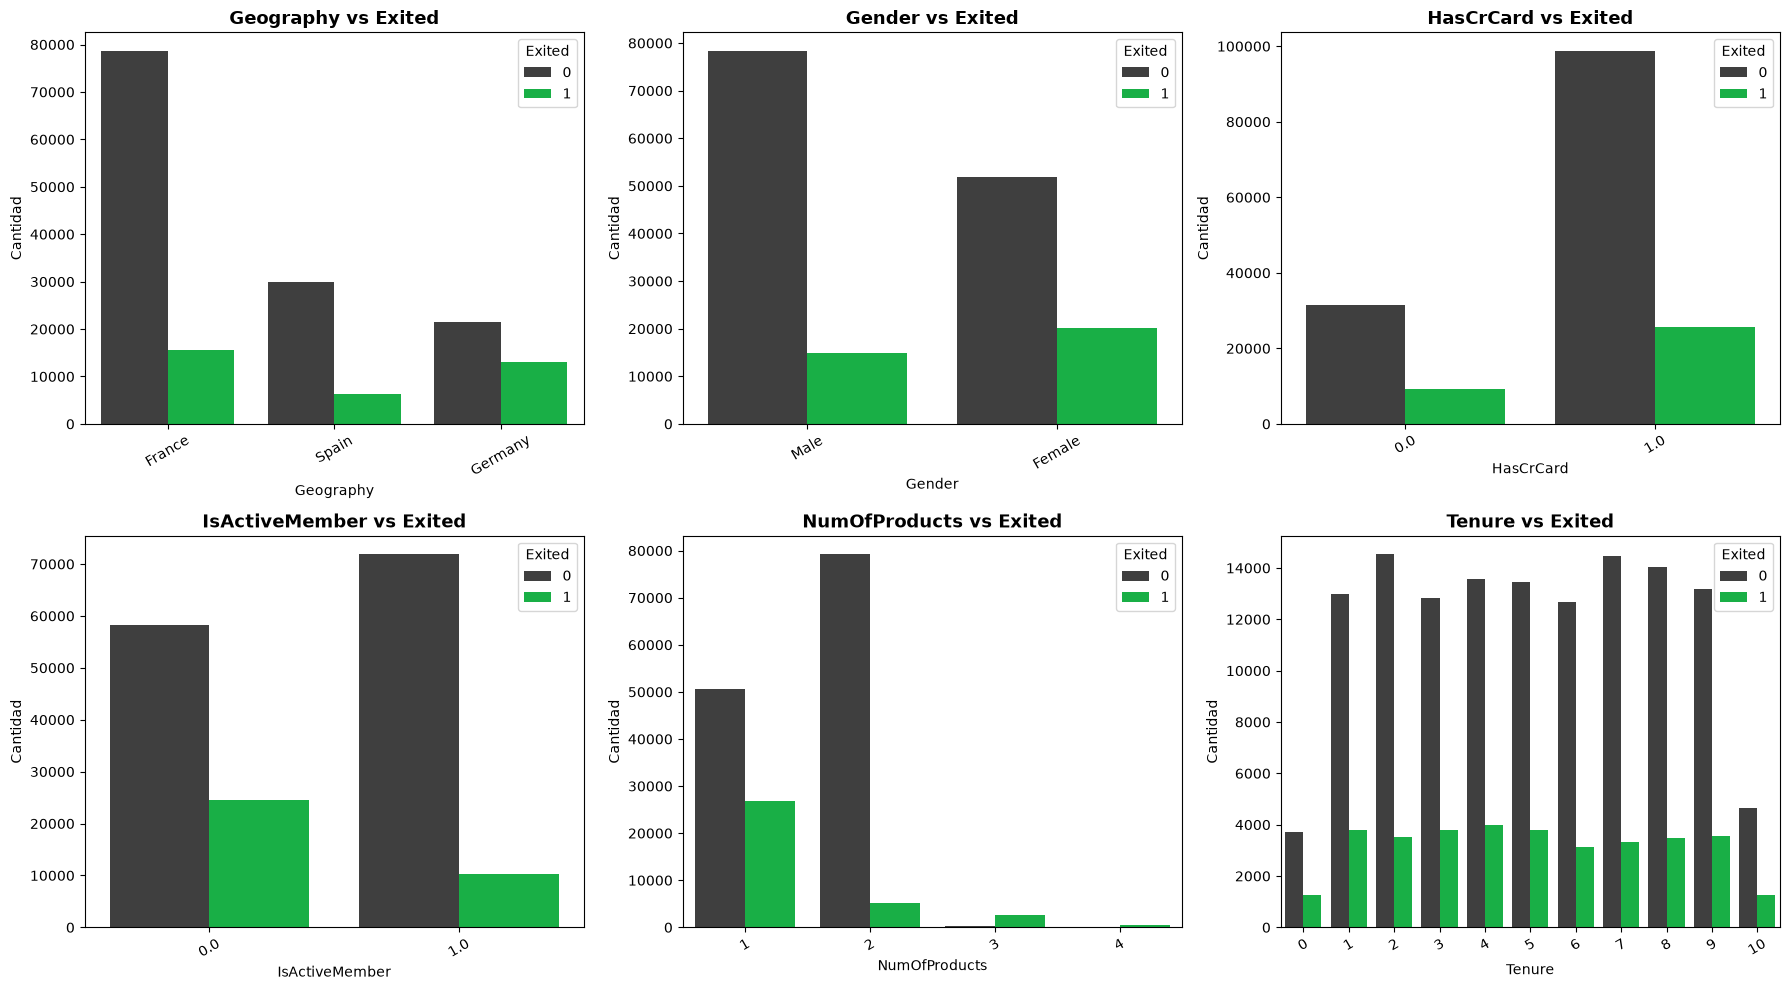

In [12]:
variables = ['Geography','Gender','HasCrCard','IsActiveMember','NumOfProducts', 'Tenure']

plot_categorical_vs_target(df=df, variables=variables, target='Exited', nrows=2, ncols=3, figsize=(18,10))

Podemos ver que si bien las clases se encuentran desbalanceadas, la distribución de estas no son iguales para todas las categorias de las variables categoricas. Por ejemplo con el caso del país del cliente, hay mayor % de clientes en churn en Alemania que en los otros 2 paises (Francia y España).

In [13]:
ctabla=pd.crosstab(df['Geography'],df['Exited'],margins=True, normalize=0).round(3)
ctabla

Exited,0,1
Geography,,
France,0.835,0.165
Germany,0.621,0.379
Spain,0.828,0.172
All,0.788,0.212


Por medio del chi2_contingency se puede ver la asociación estadistica de dos variables categoricas, en donde si se rechaza la hipotesis nulas significa que existe asoción. Esto da una aproximación sobre que variables categoricas pueden tener un poder predictivo sobre la variable dependiente.

En este caso para el país, hay significancia.

In [14]:
c, p, dof, expected = chi2_contingency(pd.crosstab(df['Geography'],df['Exited'],margins=True)) 
print(p)

0.0


En el caso del Genero se ve que persiste mayor % de churn en el sexo femenino.

In [15]:
ctabla=pd.crosstab(df['Gender'],df['Exited'],margins=True, normalize=0).round(3)
ctabla

Exited,0,1
Gender,,
Female,0.720,0.280
Male,0.841,0.159
All,0.788,0.212


Tambien hay significancia.

In [16]:
c, p, dof, expected = chi2_contingency(pd.crosstab(df['Gender'],df['Exited'],margins=True)) 
print(p)

0.0


In [17]:
c, p, dof, expected = chi2_contingency(pd.crosstab(df['HasCrCard'],df['Exited'],margins=True)) 
if p < 0.05:
    print("Existe una relación significativa entre las variables.")
else:
    print("No existe una relación significativa entre las variables.")
    
ctabla=pd.crosstab(df['HasCrCard'],df['Exited'],margins=True, normalize=0).round(3)
ctabla


Existe una relación significativa entre las variables.


Exited,0,1
HasCrCard,,
0.0,0.773,0.227
1.0,0.794,0.206
All,0.788,0.212


In [18]:
c, p, dof, expected = chi2_contingency(pd.crosstab(df['IsActiveMember'],df['Exited'],margins=True)) 
if p < 0.05:
    print("Existe una relación significativa entre las variables.")
else:
    print("No existe una relación significativa entre las variables.")
    
ctabla=pd.crosstab(df['IsActiveMember'],df['Exited'],margins=True, normalize=0).round(3)
ctabla


Existe una relación significativa entre las variables.


Exited,0,1
IsActiveMember,,
0.0,0.703,0.297
1.0,0.875,0.125
All,0.788,0.212


In [19]:
c, p, dof, expected = chi2_contingency(pd.crosstab(df['NumOfProducts'],df['Exited'],margins=True)) 
if p < 0.05:
    print("Existe una relación significativa entre las variables.")
else:
    print("No existe una relación significativa entre las variables.")
    
ctabla=pd.crosstab(df['NumOfProducts'],df['Exited'],margins=True, normalize=0).round(3)
ctabla


Existe una relación significativa entre las variables.


Exited,0,1
NumOfProducts,,
1,0.653,0.347
2,0.940,0.060
3,0.117,0.883
4,0.124,0.876
All,0.788,0.212


In [20]:
def plot_histograms(
    df,
    variables,
    nrows,
    ncols,
    bins=30,
    figsize=(16, 10)
):
    """
    Grafica múltiples histogramas de variables numéricas con
    líneas de media y mediana.

    Parámetros
    ----------
    df : pandas.DataFrame
        Dataset.

    variables : list
        Lista de variables numéricas.

    nrows : int
        Número de filas.

    ncols : int
        Número de columnas.

    bins : int, default=30
        Número de intervalos del histograma.

    figsize : tuple
        Tamaño de la figura.
    """

    # Colores corporativos
    color_hist = "#00c83c"     # Verde
    color_mean = "#00c83c"     # Media
    color_median = "#3f3f3f"   # Mediana

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.array(axes).flatten()

    for i, var in enumerate(variables):

        media = df[var].mean()
        mediana = df[var].median()

        sns.histplot(
            data=df,
            x=var,
            bins=bins,
            kde=True,
            color=color_hist,
            edgecolor="white",
            alpha=0.75,
            ax=axes[i]
        )

        # Línea de la media
        axes[i].axvline(
            media,
            color=color_mean,
            linestyle="--",
            linewidth=2,
            label=f"Media: {media:.2f}"
        )

        # Línea de la mediana
        axes[i].axvline(
            mediana,
            color=color_median,
            linestyle="-",
            linewidth=2,
            label=f"Mediana: {mediana:.2f}"
        )

        axes[i].set_title(
            f"{var}\nMedia={media:.2f} | Mediana={mediana:.2f}",
            fontsize=12,
            fontweight="bold"
        )

        axes[i].set_xlabel(var)
        axes[i].set_ylabel("Frecuencia")
        axes[i].legend()

    # Eliminar ejes vacíos
    for j in range(len(variables), len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

### Analisis Exploratorio sobre variables Númericas

Se puede ver por medio de los estadisticos que no existe normalidad en estas variables númericas. Esto también se complementa con los histogramas y con la diferencia de media y mediana, en donde en los casos que existe normalidad, estas dos metricas terminan siendo iguales, sin embargo, se ve que en todas las variables no terminan siendo iguales.

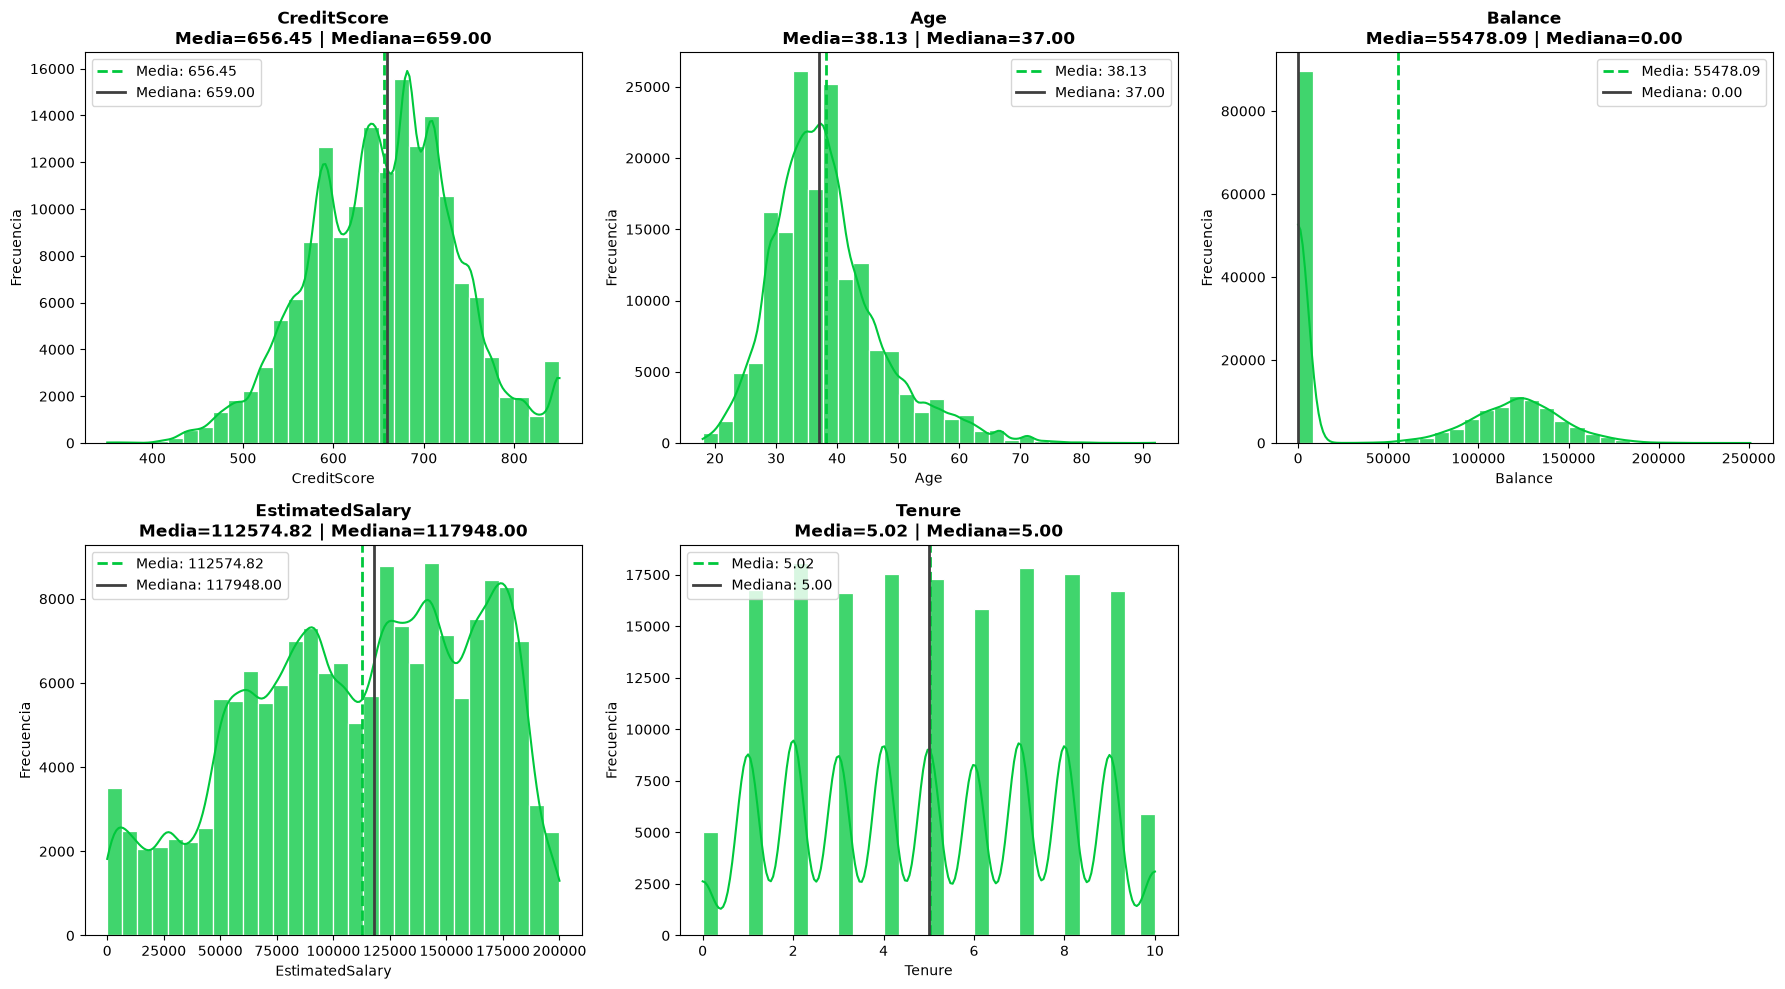

In [21]:
variables = ["CreditScore","Age","Balance","EstimatedSalary","Tenure"]

plot_histograms(df=df,variables=variables,nrows=2,ncols=3,bins=30,figsize=(18,10))

In [22]:
def dagostino_normality_test(df, variables, alpha=0.05):
    """
    Aplica el test de normalidad D'Agostino K² a múltiples variables.

    Parámetros
    ----------
    df : pandas.DataFrame
        Dataset.

    variables : list
        Lista de variables numéricas.

    alpha : float, default=0.05
        Nivel de significancia.

    Retorna
    -------
    None
        Imprime el resultado para cada variable.
    """

    print("=" * 60)
    print("TEST DE NORMALIDAD D'AGOSTINO K²")
    print("=" * 60)

    for var in variables:

        datos = df[var].dropna()

        stat, p = normaltest(datos)

        print(f"\nVariable: {var}")
        print(f"Estadístico K² : {stat:.4f}")
        print(f"P-value        : {p:.6f}")

        if p < alpha:
            print("Se rechaza H₀: La variable NO sigue una distribución normal.")
        else:
            print("No se rechaza H₀: La variable podría seguir una distribución normal.")

#### TEST DE NORMALIDAD D'AGOSTINO K²

In [23]:
variables = ["CreditScore","Age","Balance","EstimatedSalary","Tenure"]

dagostino_normality_test(df, variables)

TEST DE NORMALIDAD D'AGOSTINO K²

Variable: CreditScore
Estadístico K² : 129.9889
P-value        : 0.000000
Se rechaza H₀: La variable NO sigue una distribución normal.

Variable: Age
Estadístico K² : 24165.4300
P-value        : 0.000000
Se rechaza H₀: La variable NO sigue una distribución normal.

Variable: Balance
Estadístico K² : 811358.2734
P-value        : 0.000000
Se rechaza H₀: La variable NO sigue una distribución normal.

Variable: EstimatedSalary
Estadístico K² : 19399.7886
P-value        : 0.000000
Se rechaza H₀: La variable NO sigue una distribución normal.

Variable: Tenure
Estadístico K² : 102610.8824
P-value        : 0.000000
Se rechaza H₀: La variable NO sigue una distribución normal.


#### TEST DE ANOVA (DIFERENCIA DE MEDIAS)

Para todas las variables se aplica una prueba de diferencia de medias con la variable dependiente, esto con el fin si hay diferencia de medias entre cada una.

Para esta ocasión todas resultan ser significativas

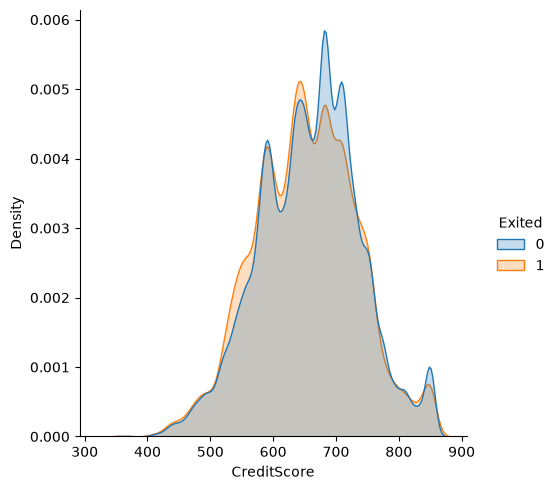

Existe diferencia de medias


In [24]:
sns.displot(x=(df['CreditScore']), kind="kde", fill=True, hue=df['Exited'], common_norm=False)
plt.show()

fvalue, p = f_oneway(df.loc[df["Exited"]==0,['CreditScore']], df.loc[df["Exited"]==1,['CreditScore']])

if p < 0.05:
    print("Existe diferencia de medias")
else:
    print("No existe diferencia de medias.")

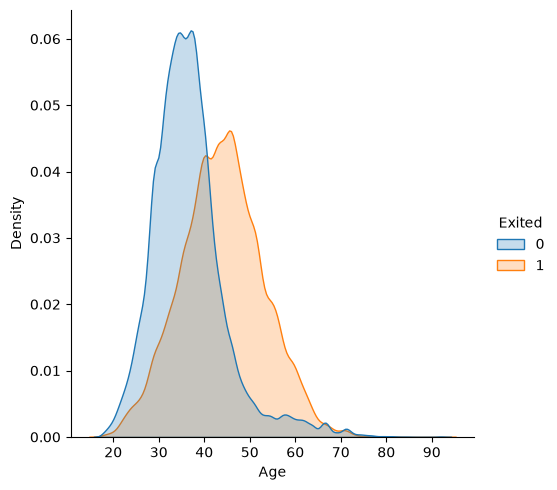

Existe diferencia de medias


In [25]:
sns.displot(x=(df['Age']), kind="kde", fill=True, hue=df['Exited'], common_norm=False)
plt.show()

fvalue, p = f_oneway(df.loc[df["Exited"]==0,['Age']], df.loc[df["Exited"]==1,['Age']])

if p < 0.05:
    print("Existe diferencia de medias")
else:
    print("No existe diferencia de medias.")

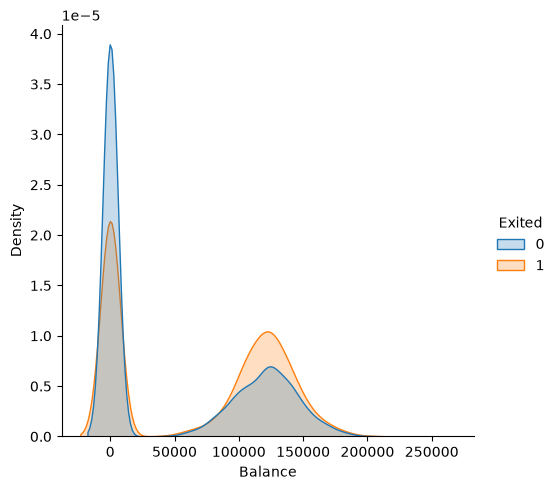

Existe diferencia de medias


In [26]:
sns.displot(x=(df['Balance']), kind="kde", fill=True, hue=df['Exited'], common_norm=False)
plt.show()

fvalue, p = f_oneway(df.loc[df["Exited"]==0,['Balance']], df.loc[df["Exited"]==1,['Balance']])

if p < 0.05:
    print("Existe diferencia de medias")
else:
    print("No existe diferencia de medias.")

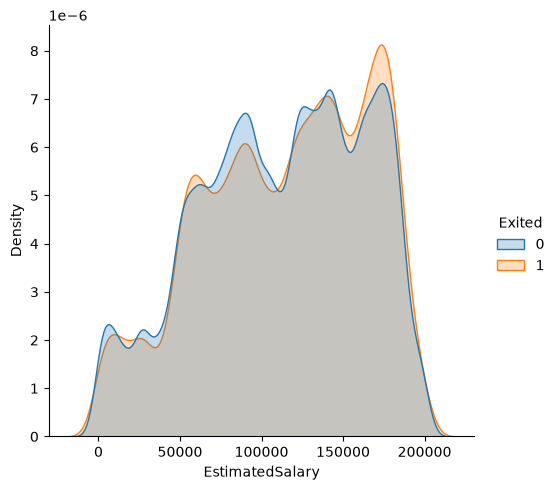

Existe diferencia de medias


In [27]:
sns.displot(x=(df['EstimatedSalary']), kind="kde", fill=True, hue=df['Exited'], common_norm=False)
plt.show()

fvalue, p = f_oneway(df.loc[df["Exited"]==0,['EstimatedSalary']], df.loc[df["Exited"]==1,['EstimatedSalary']])

if p < 0.05:
    print("Existe diferencia de medias")
else:
    print("No existe diferencia de medias.")

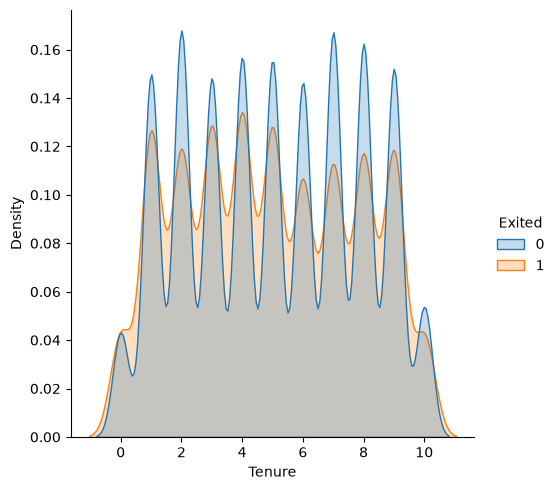

Existe diferencia de medias


In [28]:
sns.displot(x=(df['Tenure']), kind="kde", fill=True, hue=df['Exited'], common_norm=False)
plt.show()


fvalue, p = f_oneway(df.loc[df["Exited"]==0,['Tenure']], df.loc[df["Exited"]==1,['Tenure']])

if p < 0.05:
    print("Existe diferencia de medias")
else:
    print("No existe diferencia de medias.")

In [29]:
df.columns

Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited'],
      dtype='str')

### Feature Engineering - Modelos

Dado que se busca la generación de un resultado reproducible, la creación de variables, transformaciones y demas se realizaran sobre un pipeline, que debe primero ajustarse a los datos de entrenamiento. Así mismo se iterara sobre diferentes modelos,

In [4]:
X = df.drop(columns="Exited")

y = df["Exited"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

#### Primera Iteración

In [31]:
class FeatureEngineering(BaseEstimator, TransformerMixin):

    def __init__(self):
        pass

    def fit(self, X, y=None):
        return self

    def transform(self, X):

        X = X.copy()

        # 1. Balance por producto
        X["BalancePerProduct"] = (
            X["Balance"] /
            X["NumOfProducts"].replace(0, np.nan)
        )

        X["BalancePerProduct"] = X["BalancePerProduct"].fillna(0)

        # 2. Grupo de edad
        bins = [18, 30, 40, 50, 60, np.inf]
        labels = [
            "18-30",
            "31-40",
            "41-50",
            "51-60",
            "60+"
        ]

        X["AgeGroup"] = pd.cut(
            X["Age"],
            bins=bins,
            labels=labels,
            include_lowest=True
        )

        # 3. Tiene balance
        X["HasBalance"] = (
            X["Balance"] > 0
        ).astype(int)

        # 4. Cliente comprometido
        X["EngagedCustomer"] = (
            (X["IsActiveMember"] == 1) &
            (X["NumOfProducts"] >= 2)
        ).astype(int)

        # 5. Antigüedad relativa
        X["TenureAgeRatio"] = (
            X["Tenure"] /
            X["Age"]
        )

        # 6. Balance / Salario
        X["BalanceSalaryRatio"] = (
            X["Balance"] /
            (X["EstimatedSalary"] + 1)
        )

        return X

In [32]:
numeric_features = [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "EstimatedSalary",
    "BalancePerProduct",
    "HasBalance",
    "EngagedCustomer",
    "TenureAgeRatio",
    "BalanceSalaryRatio"
]

categorical_features = [
    "Gender",
    "Geography",
    "AgeGroup"
]

In [33]:
preprocessor = ColumnTransformer(

    transformers=[

        (
            "num",
            StandardScaler(),
            numeric_features
        ),

        (
            "cat",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore"
            ),
            categorical_features
        )

    ]

)


pipeline = Pipeline([

    ("feature_engineering", FeatureEngineering()),

    ("preprocessing", preprocessor),

    ("model", LogisticRegression())
])

In [34]:
models = {

    "LogisticRegression": LogisticRegression(),

    "RandomForest": RandomForestClassifier(),

    "GradientBoosting": GradientBoostingClassifier()

}

In [35]:
param_grids = {

    "LogisticRegression": {

        "model__C": [0.01, 0.1, 1, 10]

    },

    "RandomForest": {

        "model__n_estimators": [100, 200],

        "model__max_depth": [5, 10, 15]

    },

    "GradientBoosting": {

        "model__learning_rate": [0.01, 0.1],

        "model__n_estimators": [100, 200]

    }

}

In [36]:
results = {}

for name, model in models.items():

    pipeline = Pipeline([

        ("feature_engineering", FeatureEngineering()),

        ("preprocessing", preprocessor),

        ("model", model)

    ])

    grid = GridSearchCV(

        estimator=pipeline,

        param_grid=param_grids[name],

        cv=5,

        scoring="f1",

        n_jobs=-1

    )

    grid.fit(X_train, y_train)

    results[name] = {

        "Best Score": grid.best_score_,

        "Best Params": grid.best_params_,

        "Best Model": grid.best_estimator_

    }

In [37]:
for model, result in results.items():

    print("=" * 60)

    print(model)

    print(f"Best F1: {result['Best Score']:.4f}")

    print(result["Best Params"])

LogisticRegression
Best F1: 0.5229
{'model__C': 10}
RandomForest
Best F1: 0.5982
{'model__max_depth': 15, 'model__n_estimators': 100}
GradientBoosting
Best F1: 0.6113
{'model__learning_rate': 0.1, 'model__n_estimators': 200}


In [39]:
metricas = []

for model_name, result in results.items():

    model = result["Best Model"]

    y_pred = model.predict(X_test)

    metricas.append({

        "Modelo": model_name,

        "Accuracy": accuracy_score(y_test, y_pred),

        "Precision": precision_score(y_test, y_pred),

        "Recall": recall_score(y_test, y_pred),

        "F1": f1_score(y_test, y_pred)

    })

df_results = pd.DataFrame(metricas)

df_results.sort_values(
    by="F1",
    ascending=False
)

,Modelo,Accuracy,Precision,Recall,F1
2,GradientBoosting,0.856758,0.723366,0.523053,0.607113
1,RandomForest,0.855031,0.725538,0.506443,0.596509
0,LogisticRegression,0.835429,0.681393,0.417383,0.517670


In [11]:
def plot_ks(results, model_name, X_test, y_test):
    """
    Grafica la curva de Kolmogorov-Smirnov (KS).

    Parameters
    ----------
    results : dict
        Diccionario donde están almacenados los modelos.
    model_name : str
        Nombre del modelo dentro de results.
    X_test : pd.DataFrame
    y_test : pd.Series
    """

    # Pipeline entrenado
    pipeline = results[model_name]["Best Model"]

    # Probabilidades de la clase positiva (Exited = 1)
    y_score = pipeline.predict_proba(X_test)[:, 1]

    # Crear DataFrame
    ks_df = pd.DataFrame({
        "target": y_test,
        "score": y_score
    })

    # Ordenar de menor a mayor score
    ks_df = ks_df.sort_values("score")

    # Eventos y no eventos
    ks_df["event"] = (ks_df["target"] == 1).astype(int)
    ks_df["non_event"] = (ks_df["target"] == 0).astype(int)

    # Distribuciones acumuladas
    ks_df["cum_event"] = ks_df["event"].cumsum() / ks_df["event"].sum()
    ks_df["cum_non_event"] = ks_df["non_event"].cumsum() / ks_df["non_event"].sum()

    # Estadístico KS
    ks_df["ks"] = np.abs(
        ks_df["cum_event"] - ks_df["cum_non_event"]
    )

    ks_max = ks_df["ks"].max()
    idx = ks_df["ks"].idxmax()

    threshold = ks_df.loc[idx, "score"]

    # -----------------------------
    # Gráfico
    # -----------------------------
    plt.figure(figsize=(9,6))

    plt.plot(
        ks_df["score"],
        ks_df["cum_event"],
        color="red",
        label="Cumulative events",
        linewidth=2
    )

    plt.plot(
        ks_df["score"],
        ks_df["cum_non_event"],
        color="blue",
        label="Cumulative non-events",
        linewidth=2
    )

    plt.vlines(
        threshold,
        ymin=ks_df.loc[idx, "cum_event"],
        ymax=ks_df.loc[idx, "cum_non_event"],
        color="black",
        linestyle="--"
    )

    plt.text(
        threshold + 0.01,
        (ks_df.loc[idx, "cum_event"] + ks_df.loc[idx, "cum_non_event"]) / 2,
        f"KS: {ks_max:.2%} at {threshold:.2f}",
        fontsize=11
    )

    plt.xlabel("Threshold", fontsize=12)
    plt.ylabel("Cumulative probability", fontsize=12)
    plt.title(f"Kolmogorov-Smirnov - {model_name}", fontsize=14)

    plt.legend()
    plt.grid(alpha=0.2)

    plt.show()

    print(f"KS = {ks_max:.2%}")
    print(f"Threshold óptimo = {threshold:.3f}")

En terminos del Kolmogorov - Smirnov, el mejor modelo seria el de Gradient Boost ya que es el que mejor separa las clases y se mantiene estable entre el conjunto de entrenamiento como de Test (a diferencia del random forest que cae significativamente).

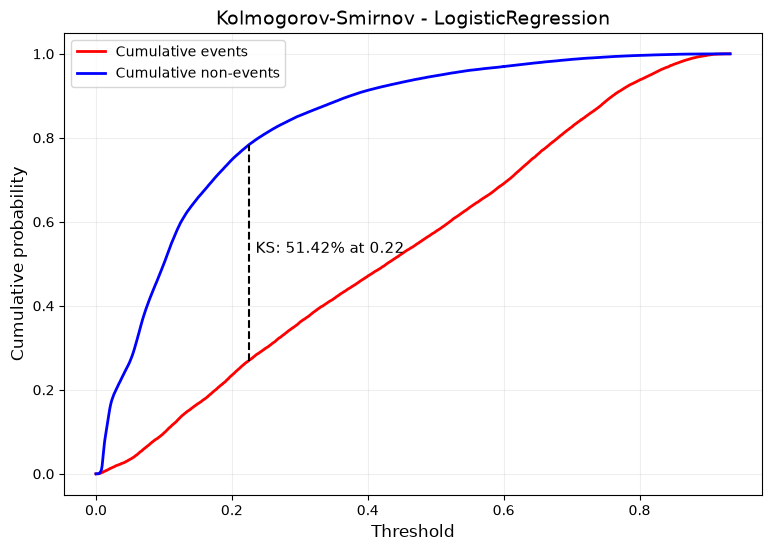

KS = 51.42%
Threshold óptimo = 0.225


In [54]:
plot_ks(
    results,
    "LogisticRegression",
    X_train,
    y_train
)

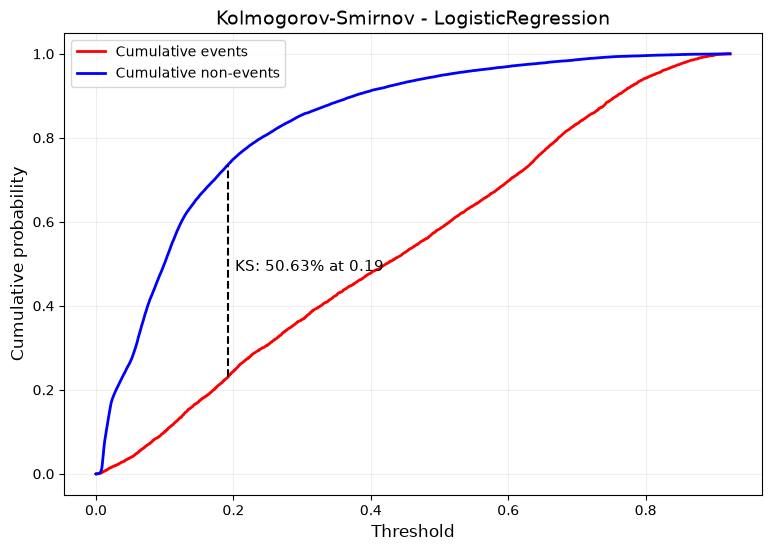

KS = 50.63%
Threshold óptimo = 0.192


In [57]:
plot_ks(
    results,
    "LogisticRegression",
    X_test,
    y_test
)

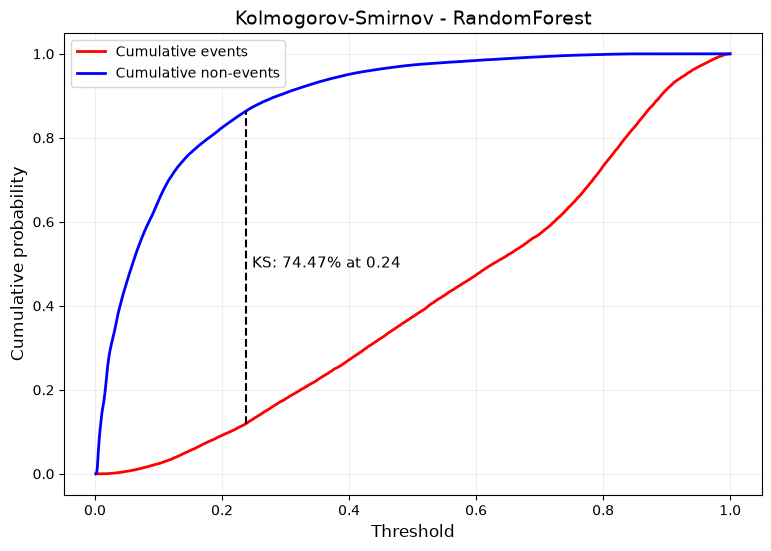

KS = 74.47%
Threshold óptimo = 0.237


In [55]:
plot_ks(
    results,
    "RandomForest",
    X_train,
    y_train
)

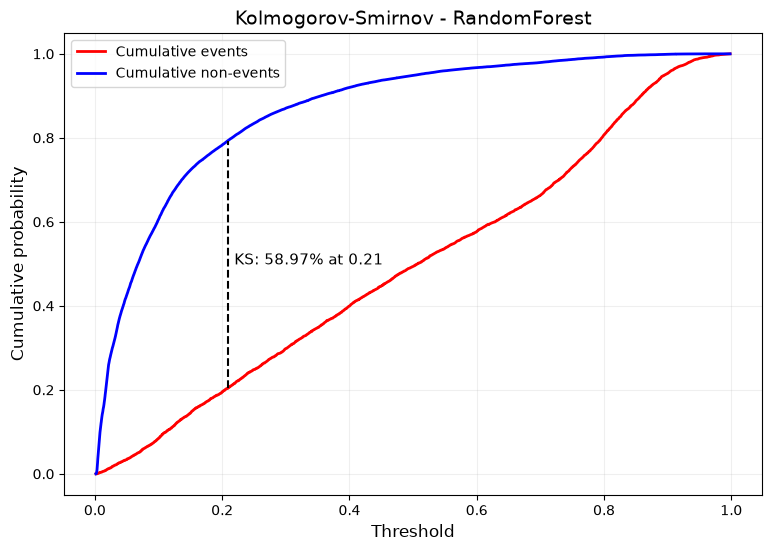

KS = 58.97%
Threshold óptimo = 0.209


In [58]:
plot_ks(
    results,
    "RandomForest",
    X_test,
    y_test
)

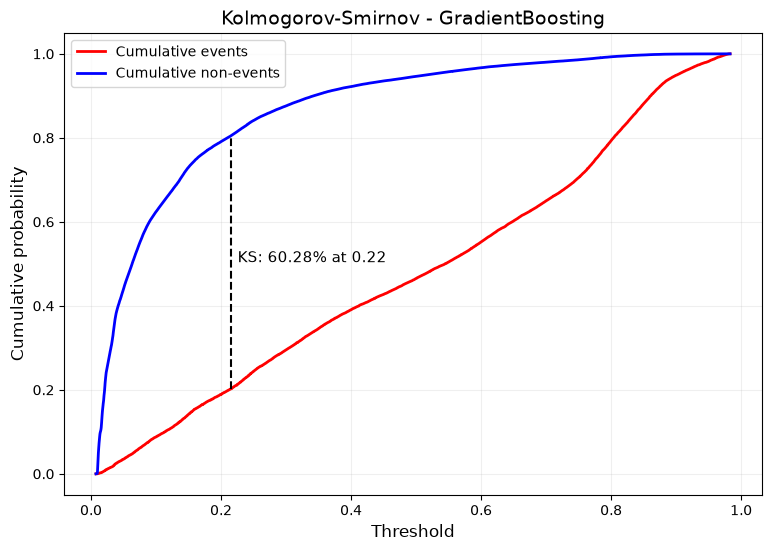

KS = 60.28%
Threshold óptimo = 0.216


In [56]:
plot_ks(
    results,
    "GradientBoosting",
    X_train,
    y_train
)

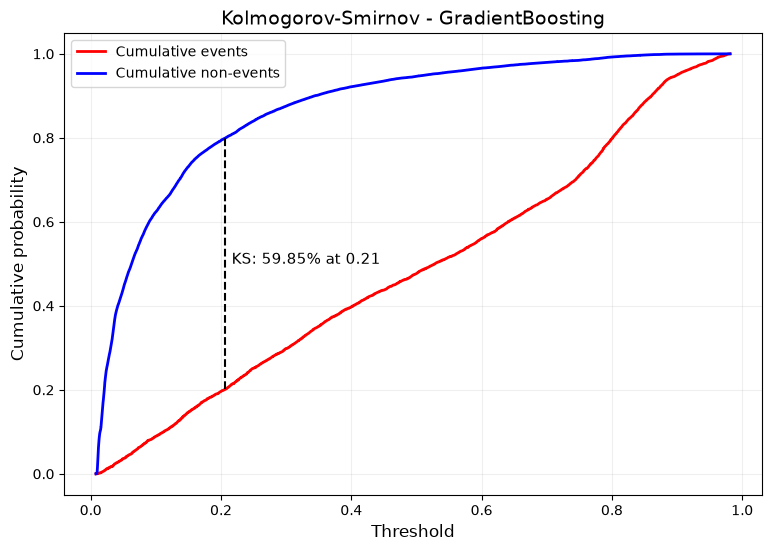

KS = 59.85%
Threshold óptimo = 0.206


In [59]:
plot_ks(
    results,
    "GradientBoosting",
    X_test,
    y_test
)

Si utilizamos el Threshould sugerido en el KS (que rondaba el 0.21) claramente aumenta el Recall, esto puede ser optimo considerando que el churn de un cliente puede ser costoso para el banco y adicionalmente no disminuye mucho el accuracy.

In [60]:
metricas = []

for model_name, result in results.items():

    model = result["Best Model"]

    y_pred_prob = model.predict_proba(X_test)[:, 1]

    y_pred = (y_pred_prob >= 0.21).astype(int) 

    metricas.append({

        "Modelo": model_name,

        "Accuracy": accuracy_score(y_test, y_pred),

        "Precision": precision_score(y_test, y_pred),

        "Recall": recall_score(y_test, y_pred),

        "F1": f1_score(y_test, y_pred)

    })

df_results = pd.DataFrame(metricas)

df_results.sort_values(
    by="F1",
    ascending=False
)

,Modelo,Accuracy,Precision,Recall,F1
2,GradientBoosting,0.801072,0.519562,0.794817,0.628368
1,RandomForest,0.794468,0.509171,0.794960,0.620751
0,LogisticRegression,0.758475,0.456322,0.738975,0.564229


In [41]:
pipeline = results["LogisticRegression"]["Best Model"]
preprocessor = pipeline.named_steps["preprocessing"]
feature_names = preprocessor.get_feature_names_out()
coef = pipeline.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({
    "Variable": feature_names,
    "Coeficiente": coef
})

coef_df["Odds Ratio"] = np.exp(coef_df["Coeficiente"])

coef_df

,Variable,Coeficiente,Odds Ratio
0,num__CreditScore,-0.062977,0.938965
1,num__Age,0.785918,2.194420
2,num__Tenure,-0.031140,0.969340
3,num__Balance,0.781236,2.184171
4,num__NumOfProducts,-0.383897,0.681201
5,num__EstimatedSalary,0.041170,1.042029
6,num__BalancePerProduct,-0.786828,0.455287
7,num__HasBalance,-0.223786,0.799486
8,num__EngagedCustomer,-0.814204,0.442992
9,num__TenureAgeRatio,-0.010945,0.989114


In [44]:
X_sample = X_test.sample(
    n=200,
    random_state=42
)

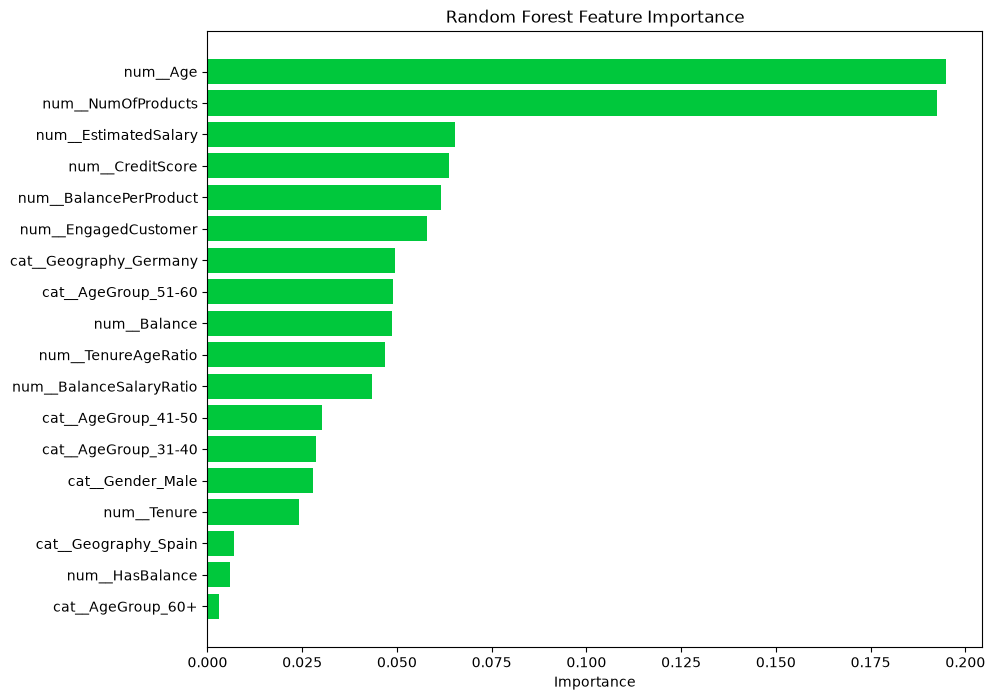

In [47]:
pipeline_rf = results["RandomForest"]["Best Model"]

preprocessor = pipeline_rf.named_steps["preprocessing"]
feature_names = preprocessor.get_feature_names_out()

rf = pipeline_rf.named_steps["model"]

importance = pd.DataFrame({
    "Variable": feature_names,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,8))

plt.barh(
    importance["Variable"][:20],
    importance["Importance"][:20],
    color="#00c83c"
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.title("Random Forest Feature Importance")

plt.show()

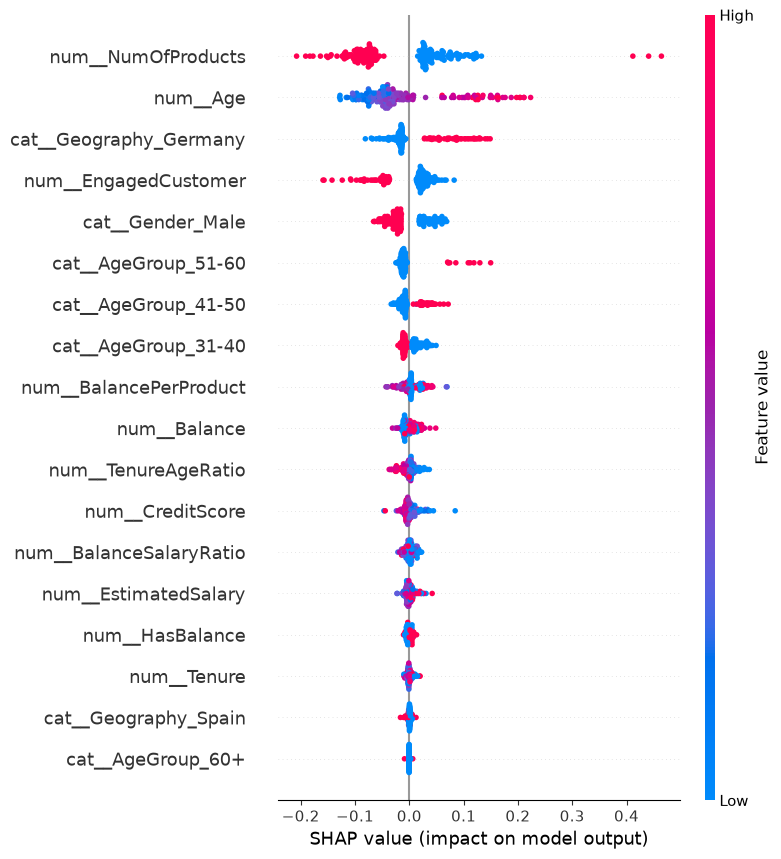

In [48]:
X_test_transformed = preprocessor.transform(
    pipeline_rf.named_steps["feature_engineering"].transform(X_sample)
)

explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(X_test_transformed)

shap.summary_plot(
    shap_values[:,:,1],
    X_test_transformed,
    feature_names=feature_names
)

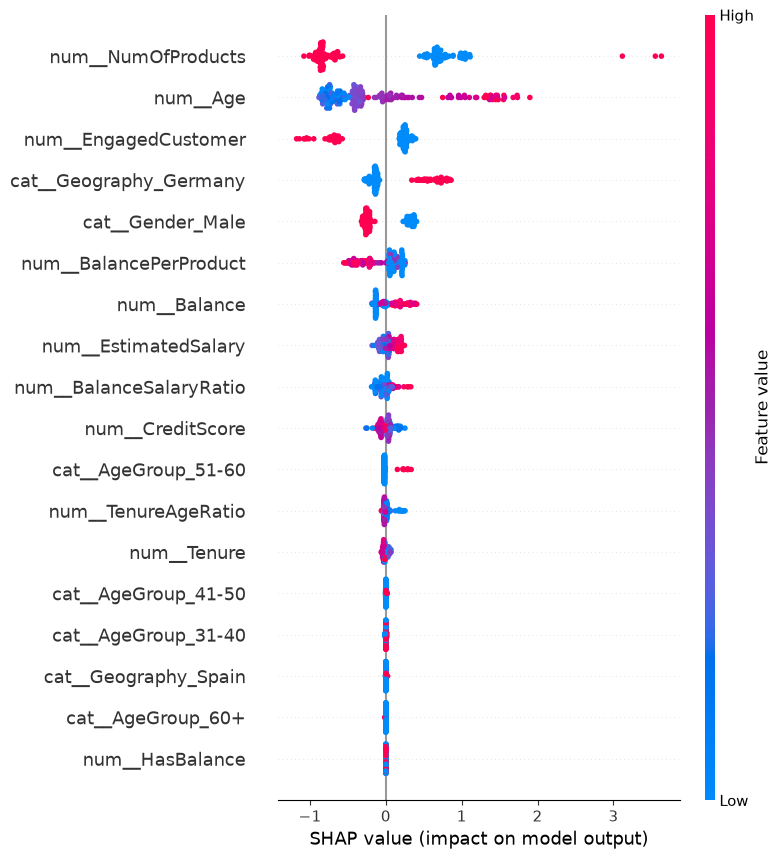

In [50]:
pipeline_gb = results["GradientBoosting"]["Best Model"]

gb = pipeline_gb.named_steps["model"]

preprocessor = pipeline_gb.named_steps["preprocessing"]

feature_names = preprocessor.get_feature_names_out()

X_test_transformed = preprocessor.transform(
    pipeline_gb.named_steps["feature_engineering"].transform(X_sample)
)

explainer = shap.TreeExplainer(gb)

shap_values = explainer.shap_values(X_test_transformed)

shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names
)

#### Segunda iteración

Se probo con la creación de variables nuevas y demas, con los resultados obtenidos anteriormente se eliminaran algunas de estas y se volveran a iterar los 3 modelos

In [65]:
class FeatureEngineering(BaseEstimator, TransformerMixin):

    def __init__(self, drop_columns=None):
        self.drop_columns = drop_columns if drop_columns is not None else []

    def fit(self, X, y=None):
        return self

    def transform(self, X):

        X = X.copy()

        # 1. Balance por producto
        X["BalancePerProduct"] = (
            X["Balance"] /
            X["NumOfProducts"].replace(0, np.nan)
        )

        X["BalancePerProduct"] = X["BalancePerProduct"].fillna(0)

        # 4. Cliente comprometido
        X["EngagedCustomer"] = (
            (X["IsActiveMember"] == 1) &
            (X["NumOfProducts"] >= 2)
        ).astype(int)

        # 5. Antigüedad relativa
        X["TenureAgeRatio"] = (
            X["Tenure"] /
            X["Age"]
        )

        X = X.drop(columns=self.drop_columns, errors="ignore")

        return X

In [5]:
from app.transformers import FeatureEngineering

In [6]:
numeric_features = [
    "CreditScore",
    "Age",
    "Balance",
    "NumOfProducts",
    "EstimatedSalary",
    "BalancePerProduct",
    "EngagedCustomer",
    "TenureAgeRatio"
]

categorical_features = [
    "Gender",
    "Geography"
]

In [7]:
preprocessor = ColumnTransformer(

    transformers=[

        (
            "num",
            StandardScaler(),
            numeric_features
        ),

        (
            "cat",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore"
            ),
            categorical_features
        )

    ]

)

pipeline = Pipeline([

    ("feature_engineering", FeatureEngineering(drop_columns=["Tenure"])),

    ("preprocessing", preprocessor),

    ("model", LogisticRegression())
])

models = {

    "LogisticRegression": LogisticRegression(),

    "RandomForest": RandomForestClassifier(),

    "GradientBoosting": GradientBoostingClassifier()

}

param_grids = {

    "LogisticRegression": {

        "model__C": [0.01, 0.1, 1, 10]

    },

    "RandomForest": {

        "model__n_estimators": [100, 200],

        "model__max_depth": [5, 10, 15]

    },

    "GradientBoosting": {

        "model__learning_rate": [0.01, 0.1],

        "model__n_estimators": [100, 200]

    }

}

In [8]:
results = {}

for name, model in models.items():

    pipeline = Pipeline([

        ("feature_engineering", FeatureEngineering()),

        ("preprocessing", preprocessor),

        ("model", model)

    ])

    grid = GridSearchCV(

        estimator=pipeline,

        param_grid=param_grids[name],

        cv=5,

        scoring="f1",

        n_jobs=-1

    )

    grid.fit(X_train, y_train)

    results[name] = {

        "Best Score": grid.best_score_,

        "Best Params": grid.best_params_,

        "Best Model": grid.best_estimator_

    }

Los resultados no terminan siendo muy distintos al anterior

In [9]:
metricas = []

for model_name, result in results.items():

    model = result["Best Model"]

    y_pred = model.predict(X_test)

    metricas.append({

        "Modelo": model_name,

        "Accuracy": accuracy_score(y_test, y_pred),

        "Precision": precision_score(y_test, y_pred),

        "Recall": recall_score(y_test, y_pred),

        "F1": f1_score(y_test, y_pred)

    })

df_results = pd.DataFrame(metricas)

df_results.sort_values(
    by="F1",
    ascending=False
)

,Modelo,Accuracy,Precision,Recall,F1
2,GradientBoosting,0.856909,0.723640,0.523769,0.607692
1,RandomForest,0.855728,0.728883,0.506586,0.597736
0,LogisticRegression,0.825461,0.665404,0.352234,0.460631


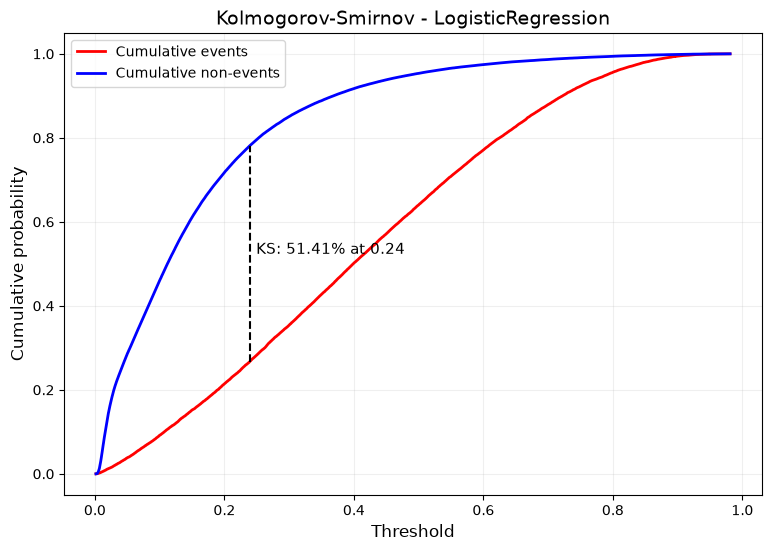

KS = 51.41%
Threshold óptimo = 0.239


In [12]:
plot_ks(
    results,
    "LogisticRegression",
    X_train,
    y_train
)

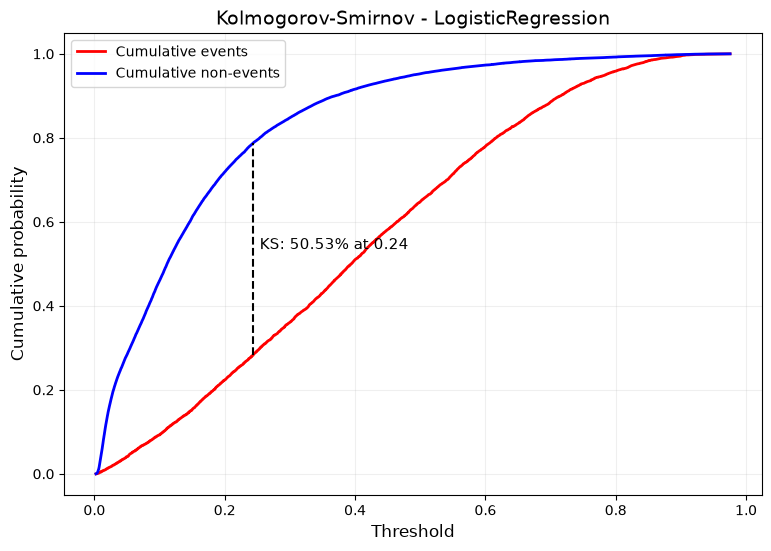

KS = 50.53%
Threshold óptimo = 0.244


In [ ]:
plot_ks(
    results,
    "LogisticRegression",
    X_test,
    y_test
)

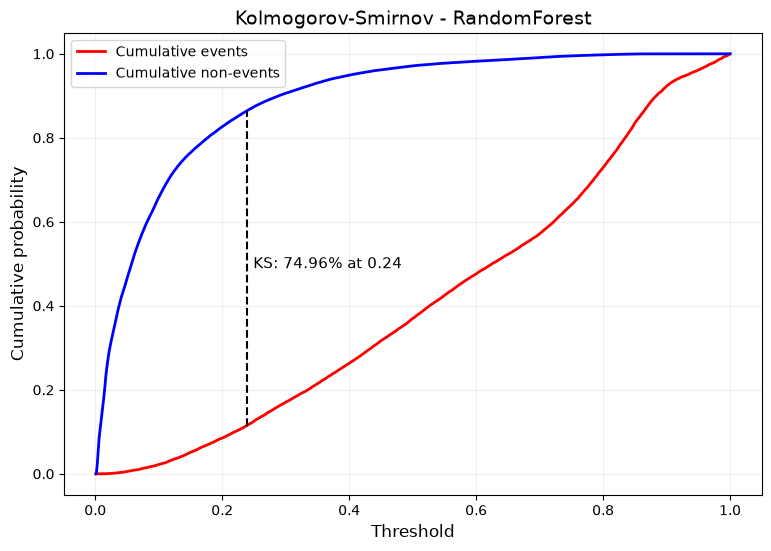

KS = 74.96%
Threshold óptimo = 0.239


In [ ]:
plot_ks(
    results,
    "RandomForest",
    X_train,
    y_train
)

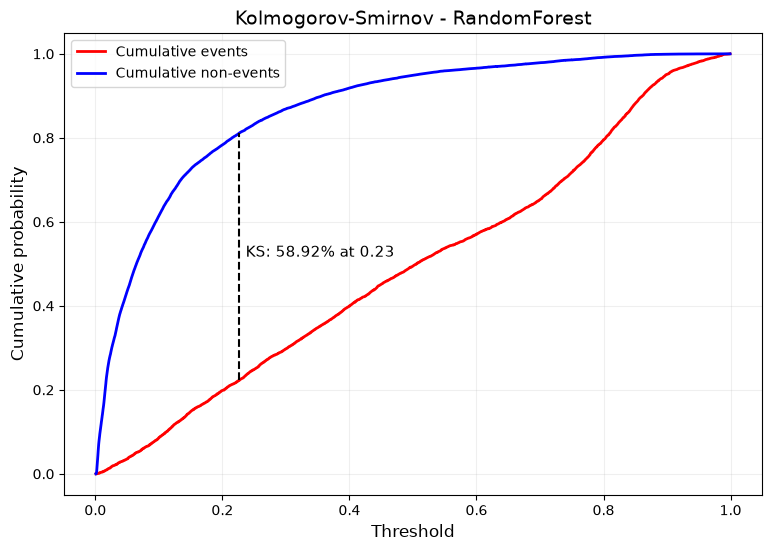

KS = 58.92%
Threshold óptimo = 0.227


In [ ]:
plot_ks(
    results,
    "RandomForest",
    X_test,
    y_test
)

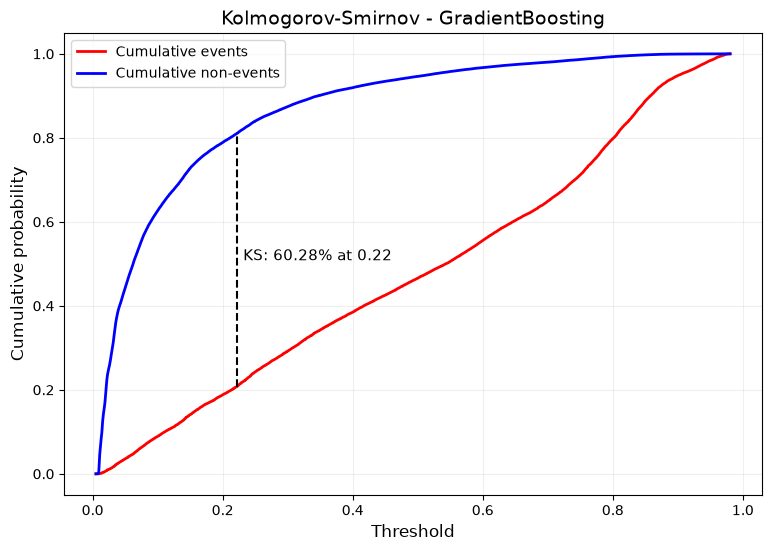

KS = 60.28%
Threshold óptimo = 0.222


In [ ]:
plot_ks(
    results,
    "GradientBoosting",
    X_train,
    y_train
)

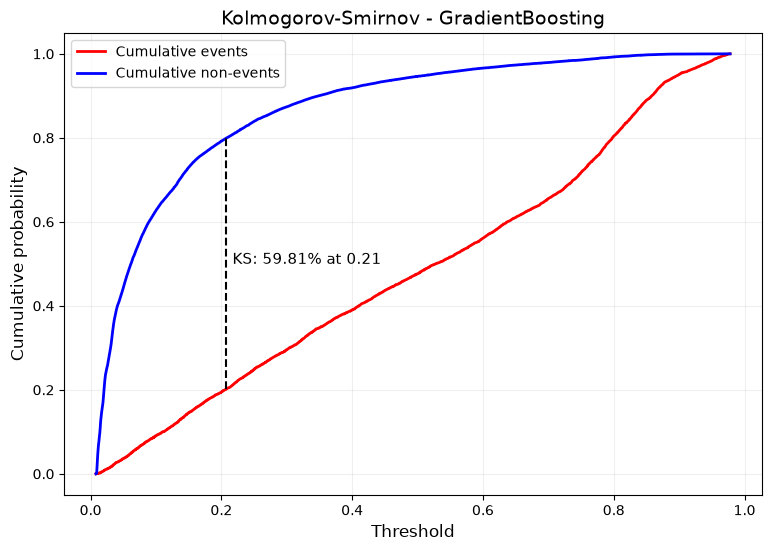

KS = 59.81%
Threshold óptimo = 0.207


In [ ]:
plot_ks(
    results,
    "GradientBoosting",
    X_test,
    y_test
)

In [ ]:
metricas = []

for model_name, result in results.items():

    model = result["Best Model"]

    y_pred_prob = model.predict_proba(X_test)[:, 1]

    y_pred = (y_pred_prob >= 0.21).astype(int) 

    metricas.append({

        "Modelo": model_name,

        "Accuracy": accuracy_score(y_test, y_pred),

        "Precision": precision_score(y_test, y_pred),

        "Recall": recall_score(y_test, y_pred),

        "F1": f1_score(y_test, y_pred)

    })

df_results = pd.DataFrame(metricas)

df_results.sort_values(
    by="F1",
    ascending=False
)

,Modelo,Accuracy,Precision,Recall,F1
2,GradientBoosting,0.800073,0.517945,0.795533,0.627407
1,RandomForest,0.793559,0.507808,0.791523,0.618691
0,LogisticRegression,0.741540,0.436572,0.762314,0.555191


In [ ]:
pipeline = results["LogisticRegression"]["Best Model"]
preprocessor = pipeline.named_steps["preprocessing"]
feature_names = preprocessor.get_feature_names_out()
coef = pipeline.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({
    "Variable": feature_names,
    "Coeficiente": coef
})

coef_df["Odds Ratio"] = np.exp(coef_df["Coeficiente"])

coef_df

,Variable,Coeficiente,Odds Ratio
0,num__CreditScore,-0.065175,0.936903
1,num__Age,0.809203,2.246117
2,num__Balance,0.591720,1.807094
3,num__NumOfProducts,-0.389297,0.677533
4,num__EstimatedSalary,0.051333,1.052673
5,num__BalancePerProduct,-0.809528,0.445068
6,num__EngagedCustomer,-0.858121,0.423958
7,num__TenureAgeRatio,-0.063239,0.938719
8,cat__Gender_Male,-0.678130,0.507565
9,cat__Geography_Germany,1.092524,2.981791


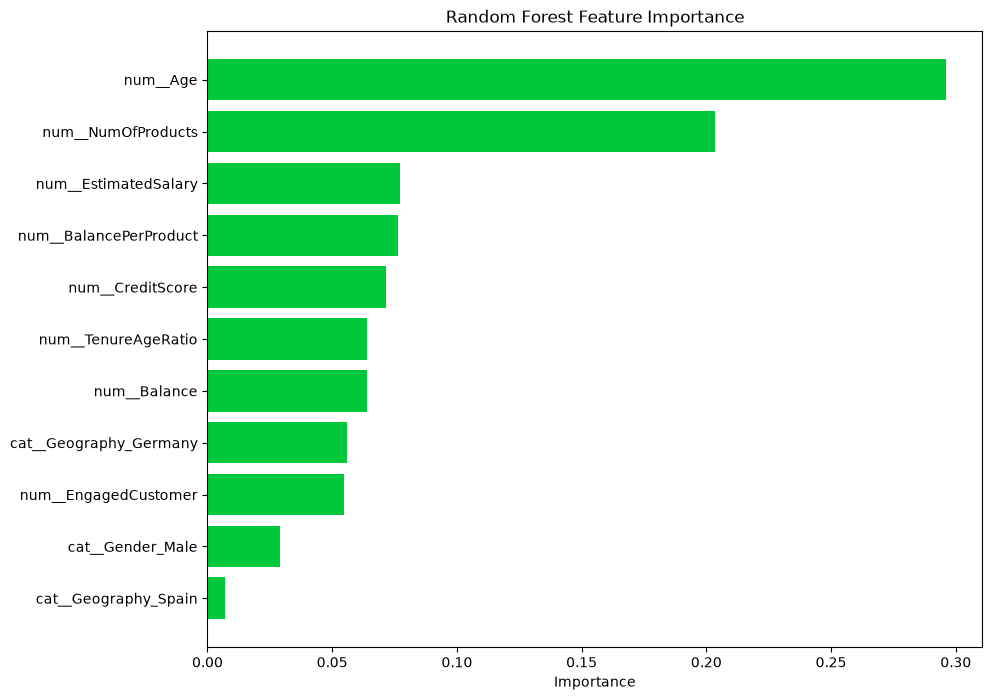

In [ ]:
pipeline_rf = results["RandomForest"]["Best Model"]

preprocessor = pipeline_rf.named_steps["preprocessing"]
feature_names = preprocessor.get_feature_names_out()

rf = pipeline_rf.named_steps["model"]

importance = pd.DataFrame({
    "Variable": feature_names,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,8))

plt.barh(
    importance["Variable"][:20],
    importance["Importance"][:20],
    color="#00c83c"
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.title("Random Forest Feature Importance")

plt.show()

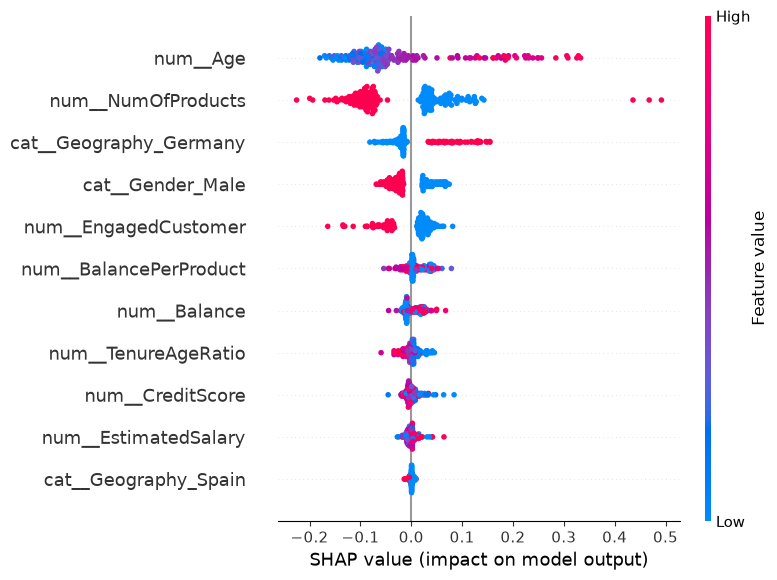

In [ ]:
X_test_transformed = preprocessor.transform(
    pipeline_rf.named_steps["feature_engineering"].transform(X_sample)
)

explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(X_test_transformed)

shap.summary_plot(
    shap_values[:,:,1],
    X_test_transformed,
    feature_names=feature_names
)

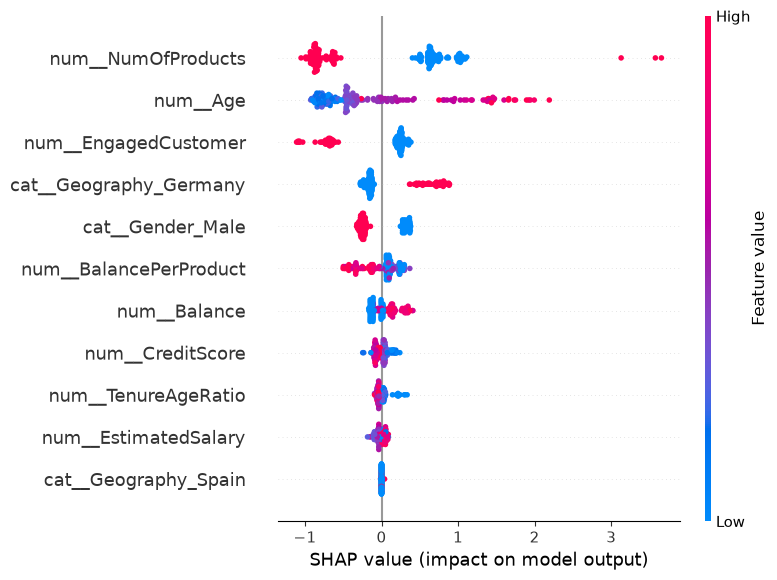

In [ ]:
pipeline_gb = results["GradientBoosting"]["Best Model"]

gb = pipeline_gb.named_steps["model"]

preprocessor = pipeline_gb.named_steps["preprocessing"]

feature_names = preprocessor.get_feature_names_out()

X_test_transformed = preprocessor.transform(
    pipeline_gb.named_steps["feature_engineering"].transform(X_sample)
)

explainer = shap.TreeExplainer(gb)

shap_values = explainer.shap_values(X_test_transformed)

shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names
)

#### Analisis PSI

In [ ]:
import numpy as np
import pandas as pd


def calculate_psi(expected, actual, bins=10):

    expected = np.asarray(expected)
    actual = np.asarray(actual)

    breakpoints = np.percentile(
        expected,
        np.arange(0, 101, 100 / bins)
    )

    expected_counts = np.histogram(
        expected,
        bins=breakpoints
    )[0]

    actual_counts = np.histogram(
        actual,
        bins=breakpoints
    )[0]

    expected_perc = expected_counts / len(expected)
    actual_perc = actual_counts / len(actual)

    expected_perc = np.where(expected_perc == 0, 0.0001, expected_perc)
    actual_perc = np.where(actual_perc == 0, 0.0001, actual_perc)

    psi = np.sum(
        (expected_perc - actual_perc) *
        np.log(expected_perc / actual_perc)
    )

    return psi

Daran PSI muy pequeños ya que los conjuntos pertenecen al mismo dataset

In [ ]:
numeric_columns = [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "EstimatedSalary"
]

psi_results = []

for col in numeric_columns:

    psi = calculate_psi(
        X_train[col],
        X_test[col]
    )

    psi_results.append({

        "Variable": col,
        "PSI": psi

    })

psi_df = pd.DataFrame(psi_results)

psi_df.sort_values(
    "PSI",
    ascending=False
)

,Variable,PSI
1,Age,0.000494
5,EstimatedSalary,0.000416
2,Tenure,0.000314
0,CreditScore,0.000209
3,Balance,0.000113
4,NumOfProducts,0.000043


In [14]:
os.makedirs("models", exist_ok=True)

joblib.dump(
    results["LogisticRegression"]["Best Model"],
    "models/logistic_pipeline.pkl"
)

joblib.dump(
    results["GradientBoosting"]["Best Model"],
    "models/gradient_pipeline.pkl"
)

print("Modelos guardados.")

Modelos guardados.


In [13]:
print(FeatureEngineering.__module__)

app.transformers
